In [ ]:
# Libraries
import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    mean_absolute_error,
    r2_score,
    silhouette_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RepeatedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

## Data Preprocess

In [3]:
# Importing data
df = pd.read_csv("../data/raw/city_accessibility_raw.csv")
print(df.columns.tolist())

['city', 'population', 'dining_access_rate', 'hotel_access_rate', 'attraction_access_rate', 'healthcare_density', 'essential_density', 'transit_density', 'bench_density', 'toilet_density', 'parking_density', 'tag_coverage_pct', 'pct_paved_streets', 'pct_good_smoothness']


In [8]:
# Handling missing values
for col in df.columns:
    if df[col].isnull().sum() >=1:
        df[col] = df[col].fillna(df[col].median())

In [13]:
# Group A: features that directly represent whether a disabled person can navigate and use the city's core amenities
group_a_cols = [
    "dining_access_rate",
    "hotel_access_rate",
    "attraction_access_rate",
    "toilet_density",
    "transit_density",
    "pct_paved_streets",
    "pct_good_smoothness",
]

In [14]:
# Group B: feature to predict the mobility score
group_b_cols = [
    "parking_density",
    "healthcare_density",
    "essential_density",
    "bench_density",
]

## Calculating Mobility Score

In [15]:
# Standardize group_a feature
scaler_a = StandardScaler()
X_group_a_scaled = scaler_a.fit_transform(df[group_a_cols])

In [16]:
# Using PCA to calculate the mobility score
pca_target = PCA(n_components=1, random_state=42)
pc1 = pca_target.fit_transform(X_group_a_scaled).flatten()
loadings = pca_target.components_[0]
if np.mean(loadings) < 0:
    loadings = -loadings
    pc1 = -pc1

print("--- PCA Feature Loadings (Empirical Weights) ---")
for col, weight in zip(group_a_cols, loadings):
    print(f"{col:25}: {weight:+.3f}")
print(f"Variance Explained by PC1: {pca_target.explained_variance_ratio_[0]*100:.2f}%\n")

df["mobility_score"] = (
    (pc1 - pc1.min()) / (pc1.max() - pc1.min()) * 100
).round(1)

print("Top 5 Scored Cities:")
print(
    df[["city", "mobility_score", "tag_coverage_pct"]]
    .sort_values("mobility_score", ascending=False)
    .head()
)

--- PCA Feature Loadings (Empirical Weights) ---
dining_access_rate       : +0.308
hotel_access_rate        : +0.313
attraction_access_rate   : +0.452
toilet_density           : +0.323
transit_density          : +0.389
pct_paved_streets        : +0.484
pct_good_smoothness      : +0.336
Variance Explained by PC1: 33.06%

Top 5 Scored Cities:
                   city  mobility_score  tag_coverage_pct
90      Munich, Germany           100.0             51.96
75       Krakow, Poland            96.4             14.27
82         Nice, France            95.7             14.25
63  Copenhagen, Denmark            95.6             21.72
53    Budapest, Hungary            93.7             21.80


#### Observation: Mobility Score Construction
- The mobility score we get through `PCA` combining & accessibility signals Group A, captures 33% of what's going across 7 signals.
- Street paving and attraction accessibility mattered the most in building the score; dining and hotel accessibility mattered the least.
- Top-scoring cities (Munich, Krakow, Nice, Copenhagen, Budapest) are mostly well-developed European cities.

## Model Prediction

In [17]:
# Dependent and Independent features
X = df[group_b_cols].copy()
y = df["mobility_score"].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Feature matrix shape: (92, 4)
Target shape: (92,)


In [ ]:
# Train-Test Split and Defining Cross Validation Folds
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cv_strategy = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

In [22]:
# Models Initialization
models = {
    "Linear Regression": Pipeline([("scaler", RobustScaler()), ("model", LinearRegression())]),
    "Ridge Regressor": Pipeline([("scaler", RobustScaler()), ("model", Ridge(alpha=1.0))]),
    "Random Forest": Pipeline([
        ("scaler", RobustScaler()),
        ("model", RandomForestRegressor(n_estimators=200, random_state=42)),
    ])
}

In [ ]:
# Model Training and Performance Metrics
print("--- 5-Fold Repeated Cross-Validation Results ---")
for name, pipe in models.items():
    mae_scores = -cross_val_score(pipe, X_train, y_train, cv=cv_strategy, scoring="neg_mean_absolute_error")
    r2_scores = cross_val_score(pipe, X_train, y_train, cv=cv_strategy, scoring="r2")
    print(f"{name:22} | CV MAE: {mae_scores.mean():.2f} (±{mae_scores.std():.2f}) | CV R²: {r2_scores.mean():.3f}")

--- 5-Fold Repeated Cross-Validation Results ---
Linear Regression      | CV MAE: 14.17 (±2.53) | CV R²: 0.388
Ridge Regressor        | CV MAE: 14.11 (±2.46) | CV R²: 0.398
Random Forest          | CV MAE: 13.97 (±2.35) | CV R²: 0.443


### Observation 
- Random Forest best among all three with R^2 of `0.443`.
- Explaining 44% of the variation in mobility_score while using only group_b features. This is good determining the size of dataset.

In [24]:
# Hyperparameter Tuning
rf_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("rf", RandomForestRegressor(random_state=42)),
])

param_grid = {
    "rf__n_estimators": [150, 250, 350],
    "rf__max_depth": [3, 4, 5],
    "rf__min_samples_leaf": [2, 4, 6],
    "rf__max_features": ["sqrt", 1.0],
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_

test_preds = best_pipeline.predict(X_test)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Test MAE: {mean_absolute_error(y_test, test_preds):.2f}")
print(f"Test R²:  {r2_score(y_test, test_preds):.3f}")

# Fit final production pipeline on all data
final_scaler = RobustScaler()
X_scaled_full = final_scaler.fit_transform(X)

rf_final = RandomForestRegressor(
    n_estimators=grid_search.best_params_["rf__n_estimators"],
    max_depth=grid_search.best_params_["rf__max_depth"],
    min_samples_leaf=grid_search.best_params_["rf__min_samples_leaf"],
    max_features=grid_search.best_params_["rf__max_features"],
    random_state=42,
)
rf_final.fit(X_scaled_full, y)

Best Parameters: {'rf__max_depth': 5, 'rf__max_features': 1.0, 'rf__min_samples_leaf': 6, 'rf__n_estimators': 250}
Test MAE: 12.46
Test R²:  0.567


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

### Observation
- After tuning we ge better Test performance (MAE `12.46`, R² `0.567`)
- Cross-validation performance (R² ≈ `0.44`) is treated as the more reliable estimate of how this model would perform on new cities, since it averages across many different train test splits rather than relying on one.

## Clustering
- Find out the Mobility Archetypes based on Group B features
- Clustering used only Group B features (secondary infrastructure) to keep it conceptually independent of the features that built mobility_score.

In [25]:

# Try a range of cluster counts (k) with two different algorithms,
k_range = range(2, 7)
clustering_results = []

# Scoring each combination on three separate validity metrics
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X_scaled_full)
    clustering_results.append({
        "Algorithm": "K-Means",
        "k": k,
        "Silhouette ↑": silhouette_score(X_scaled_full, kmeans_labels),
        "Davies-Bouldin ↓": davies_bouldin_score(X_scaled_full, kmeans_labels),
        "Calinski-Harabasz ↑": calinski_harabasz_score(X_scaled_full, kmeans_labels)
    })

    ward = AgglomerativeClustering(n_clusters=k, linkage='ward')
    ward_labels = ward.fit_predict(X_scaled_full)
    clustering_results.append({
        "Algorithm": "Hierarchical (Ward)",
        "k": k,
        "Silhouette ↑": silhouette_score(X_scaled_full, ward_labels),
        "Davies-Bouldin ↓": davies_bouldin_score(X_scaled_full, ward_labels),
        "Calinski-Harabasz ↑": calinski_harabasz_score(X_scaled_full, ward_labels)
    })

tuning_df = pd.DataFrame(clustering_results).sort_values(by="Silhouette ↑", ascending=False)
print("--- Clustering Hyperparameter Tuning Results ---")
print(tuning_df.to_string(index=False))

--- Clustering Hyperparameter Tuning Results ---
          Algorithm  k  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
            K-Means  5      0.403168          0.894060            59.262857
            K-Means  4      0.399434          0.969450            61.972497
            K-Means  2      0.390885          0.995291            72.874274
            K-Means  3      0.379345          1.099950            65.758878
Hierarchical (Ward)  5      0.376860          1.081956            52.825984
Hierarchical (Ward)  6      0.372607          0.960570            54.033541
Hierarchical (Ward)  4      0.359834          1.153882            55.657688
Hierarchical (Ward)  3      0.351627          1.041738            59.717784
            K-Means  6      0.351166          0.970720            57.463251
Hierarchical (Ward)  2      0.325456          0.960140            53.196627


### Observation
- Tested K-Means and Hierarchial (ward) Clustering across k=2 to k=6, validating across three metrics.
- K-Means with k=5 yields the best configuration. With Silhouette (`0.403`) and Davies-Bouldin (`0.894`) giving this as best configuration while Calinski-Harabaaz favours simpler k=2 split.
- K-Means outperformed Hierarchical (Ward) clustering across nearly every k tested.

###


✅ Winning Configuration: K-Means with k=5


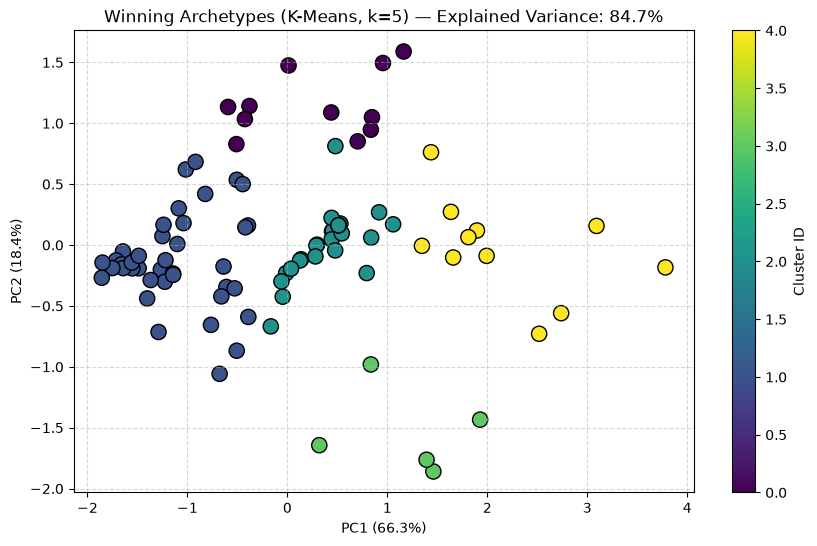

In [26]:
best_config = tuning_df.iloc[0]
best_k = int(best_config["k"])
best_algo = best_config["Algorithm"]

print(f"\n✅ Winning Configuration: {best_algo} with k={best_k}")

final_cluster_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["mobility_cluster"] = final_cluster_model.fit_predict(X_scaled_full)

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled_full)
df["pca_x"] = pca_coords[:, 0]
df["pca_y"] = pca_coords[:, 1]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df["pca_x"], df["pca_y"], c=df["mobility_cluster"], cmap="viridis", s=120, edgecolors='k')
plt.title(f"Winning Archetypes ({best_algo}, k={best_k}) — Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter, label="Cluster ID")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## SHAP Explainability


In [30]:
explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_scaled_full)

def get_top_factors(city_idx, n=3):
    """
    For a given city, returns its top N features (by SHAP importance)
    that most influenced its predicted mobility_score — showing which
    of the Group B features (parking, healthcare, essential, bench
    density) mattered most for THIS specific city, not just overall.
    """
    row_shap = shap_values[city_idx]
    order = np.argsort(-np.abs(row_shap))[:n]
    return [(group_b_cols[i], float(round(row_shap[i], 2))) for i in order]

df["top_factors"] = [get_top_factors(i) for i in range(len(df))]

In [ ]:
# Citeis with top features
sample_cities = df[["city", "mobility_score", "top_factors"]].sample(5, random_state=1).reset_index(drop=True)

# Expand the top_factors list into separate readable columns
sample_cities["Top Factor"] = sample_cities["top_factors"].apply(lambda f: f[0][0])
sample_cities["Top Factor Impact"] = sample_cities["top_factors"].apply(lambda f: round(f[0][1], 2))
sample_cities["2nd Factor"] = sample_cities["top_factors"].apply(lambda f: f[1][0])
sample_cities["3rd Factor"] = sample_cities["top_factors"].apply(lambda f: f[2][0])

display_df = sample_cities[["city", "mobility_score", "Top Factor", "Top Factor Impact", "2nd Factor", "3rd Factor"]]
display_df = display_df.rename(columns={"city": "City", "mobility_score": "Score"})

display(display_df.style.background_gradient(subset=["Top Factor Impact"], cmap="RdYlGn"))

,City,Score,Top Factor,Top Factor Impact,2nd Factor,3rd Factor
0,"Kyoto, Japan",91.000000,parking_density,16.490000,bench_density,essential_density
1,"Honolulu, United States",77.100000,parking_density,15.040000,bench_density,healthcare_density
2,"Florence, Italy",70.100000,parking_density,8.600000,bench_density,healthcare_density
3,"Dammam, Saudi Arabia",15.600000,parking_density,-24.090000,bench_density,healthcare_density
4,"Hurghada, Egypt",80.200000,parking_density,-23.310000,bench_density,healthcare_density


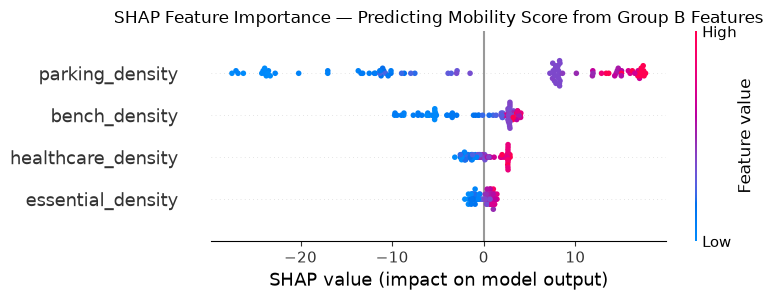

In [29]:
shap.summary_plot(shap_values, X_scaled_full, feature_names=group_b_cols, show=False)
plt.title("SHAP Feature Importance — Predicting Mobility Score from Group B Features")
plt.tight_layout()
plt.show()

### Observation
- `parking_density` and `bench_density` are the strongest predictors of mobility_score (SHAP ranges roughly -25 to +18 and -10 to +5), while `healthcare_density` and `essential_density` have minor influence.
- This makes sense for an accessibility-focused score — parking and rest areas relate directly to physical mobility, more so than healthcare or shop density.

In [32]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models", exist_ok=True)

df.to_csv("../data/processed/city_accessibility_scored.csv", index=False)
joblib.dump(rf_final, "../models/mobility_rf_model.pkl")
joblib.dump(final_scaler, "../models/mobility_scaler.pkl")
joblib.dump(final_cluster_model, "../models/mobility_kmeans.pkl")
joblib.dump(explainer, "../models/mobility_shap_explainer.pkl")

print("Saved: Scored CSV, Trained Model, RobustScaler, KMeans, and SHAP Explainer.")

Saved: Scored CSV, Trained Model, RobustScaler, KMeans, and SHAP Explainer.


## Conclusion
- Perform a split among the features to get Group A `(dining/hotel/attraction access, transit and toilet density, street paving and smoothness)` 7 core accessibility signals and get a `mobility_score` via PCA, and Group B `(parking, healthcare, essential shops, benches) ` is tested on this score to check whether it could predict an entire separate set of features.  `Random Forest` come as the best model with cross validated R^2 of `0.44`.
- Clustering on Group B features 5 distinct archetypes and SHAP analysis showed parking and bench density — both directly tied to physical mobility.